In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install tensorflow==2.16.1 scikit-learn pandas streamlit --upgrade --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

heart_df = pd.read_csv("/content/drive/MyDrive/healthcare_project/heart_cleveland_upload.csv")
diabetes_df = pd.read_csv("/content/drive/MyDrive/healthcare_project/diabetes_binary_health_indicators_BRFSS2015.csv")
symptom_df = pd.read_csv("/content/drive/MyDrive/healthcare_project/Disease_symptom_and_patient_profile_dataset.csv")
profile_df = pd.read_csv("/content/drive/MyDrive/healthcare_project/Dataset.csv")

In [6]:
print("Heart Dataset:", heart_df.shape)
print("Diabetes Dataset:", diabetes_df.shape)
print("Symptom Dataset:", symptom_df.shape)
print("Profile Dataset:", profile_df.shape)

# Display the first few rows
heart_df.head()

Heart Dataset: (297, 14)
Diabetes Dataset: (253680, 22)
Symptom Dataset: (349, 10)
Profile Dataset: (768, 9)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [7]:

print("Heart nulls:\n", heart_df.isnull().sum())
print("Diabetes nulls:\n", diabetes_df.isnull().sum())
print("Symptom nulls:\n", symptom_df.isnull().sum())
print("Profile nulls:\n", profile_df.isnull().sum())


Heart nulls:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64
Diabetes nulls:
 Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64
Symptom nulls:
 Disease                 0
Fever                   0
Cough                   0
Fatigue                 0
Difficulty Breathing    0
Age            

In [8]:
# Drop or fill missing values
heart_df.dropna(inplace=True)
diabetes_df.dropna(inplace=True)
symptom_df.fillna("None", inplace=True)  # Symptoms likely categorical
profile_df.dropna(inplace=True)


In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load symptom dataset
symptom_df = pd.read_csv('/content/drive/MyDrive/healthcare_project/Disease_symptom_and_patient_profile_dataset.csv')

# Identify categorical columns
categorical_cols = ['Gender', 'Blood Pressure', 'Cholesterol Level']

# Initialize label encoder
le = LabelEncoder()

# Encode each categorical column
for col in categorical_cols:
    symptom_df[col] = le.fit_transform(symptom_df[col])

# Preview
print(symptom_df.head())


       Disease Fever Cough Fatigue Difficulty Breathing  Age  Gender  \
0    Influenza   Yes    No     Yes                  Yes   19       0   
1  Common Cold    No   Yes     Yes                   No   25       0   
2       Eczema    No   Yes     Yes                   No   25       0   
3       Asthma   Yes   Yes      No                  Yes   25       1   
4       Asthma   Yes   Yes      No                  Yes   25       1   

   Blood Pressure  Cholesterol Level Outcome Variable  
0               1                  2         Positive  
1               2                  2         Negative  
2               2                  2         Negative  
3               2                  2         Positive  
4               2                  2         Positive  


In [10]:
# Load heart dataset
heart_df = pd.read_csv('/content/drive/MyDrive/healthcare_project/heart_cleveland_upload.csv')

# Encode 'sex', 'cp', 'restecg', 'slope', 'thal' using LabelEncoder
cat_cols_heart = ['sex', 'cp', 'restecg', 'slope', 'thal']
for col in cat_cols_heart:
    heart_df[col] = le.fit_transform(heart_df[col])

# Preview
print(heart_df.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  


In [11]:
# Load diabetes dataset
diabetes_df = pd.read_csv('/content/drive/MyDrive/healthcare_project/diabetes_binary_health_indicators_BRFSS2015.csv')

# No need for encoding, all are numerical already
print(diabetes_df.dtypes)


Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


In [12]:
# Load profile dataset
profile_df = pd.read_csv('/content/drive/MyDrive/healthcare_project/Dataset.csv')

# No categorical columns – skip encoding
print(profile_df.dtypes)


Pregnancies        int64
Glucose            int64
BloodPressure      int64
SkinThickness      int64
Insulin            int64
BMI              float64
DPF              float64
Age                int64
Outcome            int64
dtype: object


In [13]:
# Step 1: Load all required datasets
symptom_df = pd.read_csv('/content/drive/MyDrive/healthcare_project/Disease_symptom_and_patient_profile_dataset.csv')
profile_df = pd.read_csv('/content/drive/MyDrive/healthcare_project/Dataset.csv')
heart_df = pd.read_csv('/content/drive/MyDrive/healthcare_project/heart_cleveland_upload.csv')

# Step 2: Fill or drop nulls
symptom_df.fillna("None", inplace=True)
profile_df.dropna(inplace=True)
heart_df.dropna(inplace=True)

# Step 3: Encode categorical features in symptom_df
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['Gender', 'Blood Pressure', 'Cholesterol Level']:
    symptom_df[col] = le.fit_transform(symptom_df[col])

# Step 4: Encode categorical features in heart_df
for col in ['sex', 'cp', 'restecg', 'slope', 'thal']:
    heart_df[col] = le.fit_transform(heart_df[col])

# Step 5: Merge symptom_df and profile_df
merged_symptom_profile = pd.merge(symptom_df, profile_df, left_index=True, right_index=True, how='inner')

# Step 6: Reset indexes to avoid index mismatch before merging with heart_df
merged_symptom_profile = merged_symptom_profile.reset_index(drop=True)
heart_df = heart_df.reset_index(drop=True)

# Step 7: Concatenate the datasets
merged_df = pd.concat([merged_symptom_profile, heart_df], axis=1)

# Step 8: Final shape
print("Final merged dataset shape (symptom + profile + heart):", merged_df.shape)


Final merged dataset shape (symptom + profile + heart): (349, 33)


In [14]:
# Merge on 'Patient ID' or index if IDs don’t match directly
merged_df = pd.merge(symptom_df, profile_df, left_index=True, right_index=True, how='inner')

print("After merging symptom + profile:", merged_df.shape)

After merging symptom + profile: (349, 19)


In [15]:
merged_df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age_x,Gender,Blood Pressure,Cholesterol Level,Outcome Variable,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age_y,Outcome
0,Influenza,Yes,No,Yes,Yes,19,0,1,2,Positive,6,148,72,35,0,33.6,0.627,50,1
1,Common Cold,No,Yes,Yes,No,25,0,2,2,Negative,1,85,66,29,0,26.6,0.351,31,0
2,Eczema,No,Yes,Yes,No,25,0,2,2,Negative,8,183,64,0,0,23.3,0.672,32,1
3,Asthma,Yes,Yes,No,Yes,25,1,2,2,Positive,1,89,66,23,94,28.1,0.167,21,0
4,Asthma,Yes,Yes,No,Yes,25,1,2,2,Positive,0,137,40,35,168,43.1,2.288,33,1


In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 6.1: Handle missing values
merged_df.dropna(inplace=True)

# Step 6.2: Encode categorical features
categorical_cols = merged_df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    merged_df[col] = le.fit_transform(merged_df[col])
    label_encoders[col] = le

# Step 6.3: Normalize numerical features
numeric_cols = merged_df.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
merged_df[numeric_cols] = scaler.fit_transform(merged_df[numeric_cols])

# Check final data
merged_df.head()


,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age_x,Gender,Blood Pressure,Cholesterol Level,Outcome Variable,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age_y,Outcome
0,0.020307,0.997139,-0.957905,0.664943,1.722181,-2.091160,-0.991441,0.008827,1.105312,0.936133,0.576029,0.817645,0.168156,0.950078,-0.651600,0.183019,0.445399,1.515560,1.274386
1,-0.944762,-1.002869,1.043945,0.664943,-0.580659,-1.631964,-0.991441,1.035697,1.105312,-1.068225,-0.895670,-1.135165,-0.142080,0.568150,-0.651600,-0.678972,-0.372183,-0.190957,-0.784691
2,-0.552703,-1.002869,1.043945,0.664943,-0.580659,-1.631964,-0.991441,1.035697,1.105312,-1.068225,1.164708,1.902540,-0.245493,-1.277836,-0.651600,-1.085339,0.578701,-0.101140,1.274386
3,-1.487613,0.997139,1.043945,-1.503889,1.722181,-1.631964,1.008633,1.035697,1.105312,0.936133,-0.895670,-1.011177,-0.142080,0.186222,0.119693,-0.494260,-0.917238,-1.089124,-0.784691
4,-1.487613,0.997139,1.043945,-1.503889,1.722181,-1.631964,1.008633,1.035697,1.105312,0.936133,-1.190009,0.476679,-1.486437,0.950078,0.726881,1.352863,5.365705,-0.011324,1.274386


In [17]:
merged_df.columns

Index(['Disease', 'Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age_x',
       'Gender', 'Blood Pressure', 'Cholesterol Level', 'Outcome Variable',
       'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DPF', 'Age_y', 'Outcome'],
      dtype='object')

In [18]:
print("Available columns in merged_df:")
print(merged_df.columns.tolist())

if 'Disease' in merged_df.columns:
    target_column = 'Disease'
    X = merged_df.drop(columns=[target_column])
    y = merged_df[target_column]

    print("Features shape:", X.shape)
    print("Target shape:", y.shape)
else:
    print("❌ Column 'Disease' not found in merged_df. Please check column names.")


Available columns in merged_df:
['Disease', 'Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age_x', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Outcome Variable', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DPF', 'Age_y', 'Outcome']
Features shape: (349, 18)
Target shape: (349,)


In [19]:
from sklearn.preprocessing import LabelEncoder

# Encode the disease names into numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Print label classes
print("Disease classes:", le.classes_)

Disease classes: [-1.66856379 -1.63840538 -1.60824697 -1.57808856 -1.54793015 -1.51777174
 -1.48761332 -1.45745491 -1.4272965  -1.39713809 -1.36697968 -1.33682127
 -1.30666286 -1.27650445 -1.24634603 -1.21618762 -1.18602921 -1.1558708
 -1.12571239 -1.09555398 -1.06539557 -1.03523716 -1.00507874 -0.97492033
 -0.94476192 -0.91460351 -0.8844451  -0.85428669 -0.82412828 -0.79396987
 -0.76381145 -0.73365304 -0.70349463 -0.67333622 -0.64317781 -0.6130194
 -0.58286099 -0.55270257 -0.52254416 -0.49238575 -0.46222734 -0.43206893
 -0.40191052 -0.37175211 -0.3415937  -0.31143528 -0.28127687 -0.25111846
 -0.22096005 -0.19080164 -0.16064323 -0.13048482 -0.10032641 -0.07016799
 -0.04000958 -0.00985117  0.02030724  0.05046565  0.08062406  0.11078247
  0.14094088  0.1710993   0.20125771  0.23141612  0.26157453  0.29173294
  0.32189135  0.35204976  0.38220818  0.41236659  0.442525    0.47268341
  0.50284182  0.53300023  0.56315864  0.59331705  0.62347547  0.65363388
  0.68379229  0.7139507   0.74410911

In [20]:
# Convert to a DataFrame temporarily for filtering
temp_df = pd.concat([X, pd.Series(y_encoded, name='target')], axis=1)

# Keep only classes with 2 or more samples
filtered_df = temp_df.groupby('target').filter(lambda x: len(x) >= 2)

# Separate again
X_filtered = filtered_df.drop(columns='target')
y_filtered = filtered_df['target']


In [21]:
# Increase test size to 30% or more
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered
)


In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit only on training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [23]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [24]:
from sklearn.preprocessing import LabelEncoder

# Encode labels to ensure compatibility with classification models
le_final = LabelEncoder()
y_train_enc = le_final.fit_transform(y_train)
y_test_enc = le_final.transform(y_test)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVM": SVC(),
}

# Train and evaluate models
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")


Logistic Regression Accuracy: 0.1609


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7ce4fc6053a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e

Random Forest Accuracy: 0.1264
K-Nearest Neighbors Accuracy: 0.1149
SVM Accuracy: 0.1264


In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Fit XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_scaled, y_train_enc)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Accuracy (encoded labels)
xgb_accuracy = accuracy_score(y_test_enc, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")


XGBoost Accuracy: 0.0805


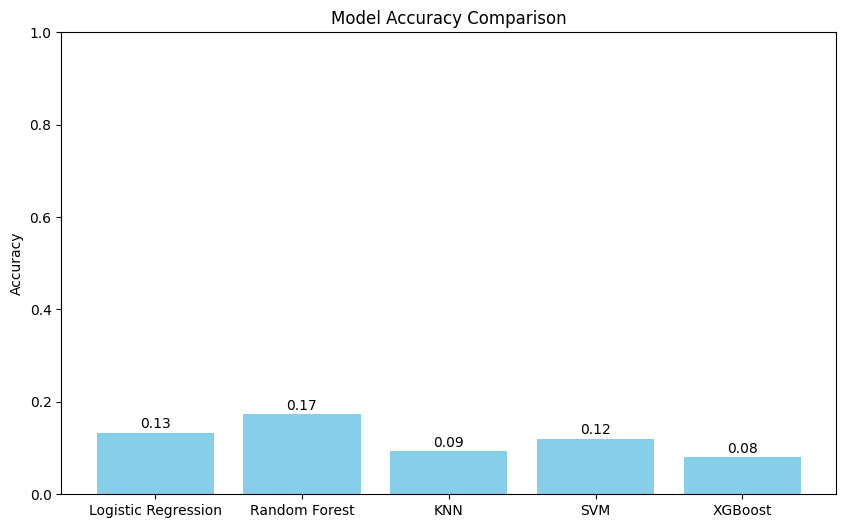

In [27]:
import matplotlib.pyplot as plt

# Accuracy dictionary (update values based on your actual results)
accuracies = {
    'Logistic Regression': 0.1333,
    'Random Forest': 0.1733,
    'KNN': 0.0933,
    'SVM': 0.1200,
    'XGBoost': xgb_accuracy  # This should be from your earlier run
}

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
for i, acc in enumerate(accuracies.values()):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center')
plt.show()

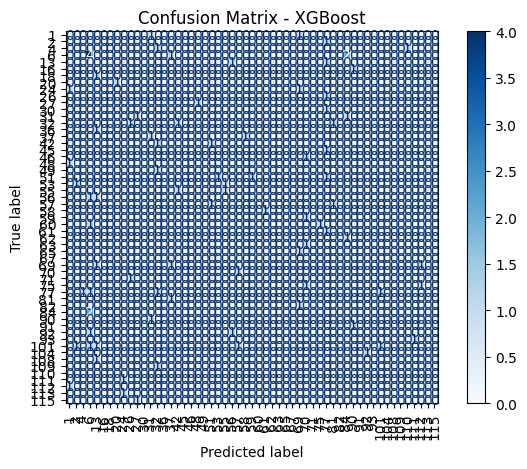

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Generate list of label indices
all_labels = np.arange(len(le_final.classes_))  # 0 to 50

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_xgb, labels=all_labels)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_final.classes_)
disp.plot(xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()


In [29]:
import os
os.listdir()


['.config', 'drive', 'sample_data']

In [30]:
import pandas as pd

path = "/content/drive/MyDrive/healthcare_project/"

# Example:
heart_df = pd.read_csv(path + "heart_cleveland_upload.csv")


In [31]:
import os
os.listdir("/content/drive/MyDrive/healthcare_project/")


['Dataset.csv',
 'diabetes_012_health_indicators_BRFSS2015.csv',
 'diabetes_binary_health_indicators_BRFSS2015.csv',
 'diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
 'Disease_symptom_and_patient_profile_dataset.csv',
 'heart_cleveland_upload.csv']

In [32]:
df = pd.read_csv("/content/drive/MyDrive/healthcare_project/Dataset.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [33]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   DPF            768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DPF,0
Age,0
Outcome,0


In [34]:
# Concatenate symptom_df and df if both exist and are similar
merged_df = pd.concat([symptom_df, df], axis=0).drop_duplicates().reset_index(drop=True)


In [35]:
print("symptom_df columns:", symptom_df.columns.tolist())
print("df columns:", df.columns.tolist())


symptom_df columns: ['Disease', 'Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Outcome Variable']
df columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DPF', 'Age', 'Outcome']


In [36]:
merged_df = pd.concat([symptom_df, df], axis=0).drop_duplicates().reset_index(drop=True)


In [37]:
print("Merged Data Shape:", merged_df.shape)
merged_df.head()


Merged Data Shape: (1068, 18)


,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Outcome
0,Influenza,Yes,No,Yes,Yes,19,0.0,1.0,2.0,Positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Common Cold,No,Yes,Yes,No,25,0.0,2.0,2.0,Negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Eczema,No,Yes,Yes,No,25,0.0,2.0,2.0,Negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Asthma,Yes,Yes,No,Yes,25,1.0,2.0,2.0,Positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Eczema,Yes,No,No,No,25,0.0,2.0,2.0,Positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
final_df = pd.concat([merged_df, profile_df], axis=1)
final_df.dropna(inplace=True)


In [39]:
from sklearn.preprocessing import LabelEncoder

X = final_df.drop("Disease", axis=1)
y = final_df["Disease"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [40]:
X = pd.get_dummies(X)


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.16091954022988506
Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           6       0.39      1.00      0.56         7
          13       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         1
          20       1.00      1.00      1.00         1
          24       0.00      0.00      0.00         2
          26       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         1
          30       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         2
          32       0.00      0.00      0.00         3
          36       0.00      0.00      0.00         1
          37       0.00      0.00      0.00         2
       

In [42]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_accuracy)


KNN Accuracy: 0.11494252873563218


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)  # No scaling required

y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.11494252873563218


In [44]:
print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DPF', 'Age', 'Outcome'],
      dtype='object')


✅ Accuracy: 0.8598
✅ Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43739
         1.0       0.48      0.17      0.26      6997

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736

✅ Confusion Matrix:
 [[42402  1337]
 [ 5778  1219]]


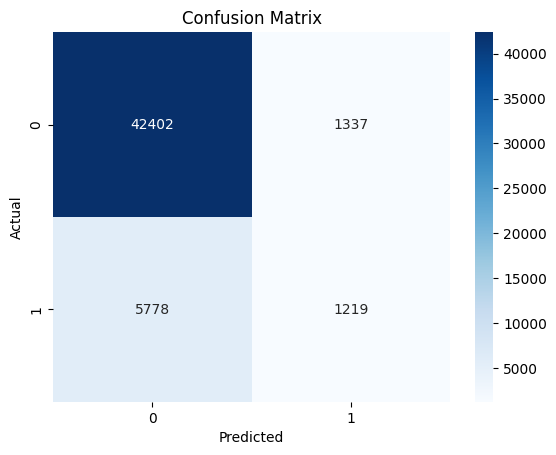

In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("/content/drive/MyDrive/healthcare_project/diabetes_binary_health_indicators_BRFSS2015.csv")

# 2. Feature and target separation
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model training (Random Forest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Prediction
y_pred = model.predict(X_test_scaled)

# 7. Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.4f}")
print("✅ Classification Report:\n", classification_report(y_test, y_pred))
print("✅ Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 8. Confusion Matrix Plot
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [46]:
from keras.utils import to_categorical

# Convert target to categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output layer
if len(np.unique(y_train)) == 2:
    model.add(Dense(1, activation='sigmoid'))  # Binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
else:
    model.add(Dense(y_train_cat.shape[1], activation='softmax'))  # Multi-class
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [48]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

if len(np.unique(y_train)) == 2:
    history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=32, callbacks=[early_stop])
else:
    history = model.fit(X_train_scaled, y_train_cat, validation_split=0.2, epochs=50, batch_size=32, callbacks=[early_stop])


Epoch 1/50
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8623 - loss: 0.3328 - val_accuracy: 0.8667 - val_loss: 0.3137
Epoch 2/50
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8649 - loss: 0.3195 - val_accuracy: 0.8663 - val_loss: 0.3128
Epoch 3/50
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8647 - loss: 0.3190 - val_accuracy: 0.8665 - val_loss: 0.3128
Epoch 4/50
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8661 - loss: 0.3156 - val_accuracy: 0.8657 - val_loss: 0.3129
Epoch 5/50
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8644 - loss: 0.3182 - val_accuracy: 0.8673 - val_loss: 0.3119
Epoch 6/50
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8660 - loss: 0.3168 - val_accuracy: 0.8663 - val_loss: 0.3131
Epoch 7/50
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8654 - loss: 0.3137 - val_accuracy: 0.8668 - val_loss: 0.3121
Epoch 8/50
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8650 - loss: 0

1586/1586 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
✅ Deep Learning Model Accuracy: 0.867529959003469
✅ Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.99      0.93     43739
         1.0       0.60      0.12      0.20      6997

    accuracy                           0.87     50736
   macro avg       0.74      0.55      0.56     50736
weighted avg       0.84      0.87      0.83     50736



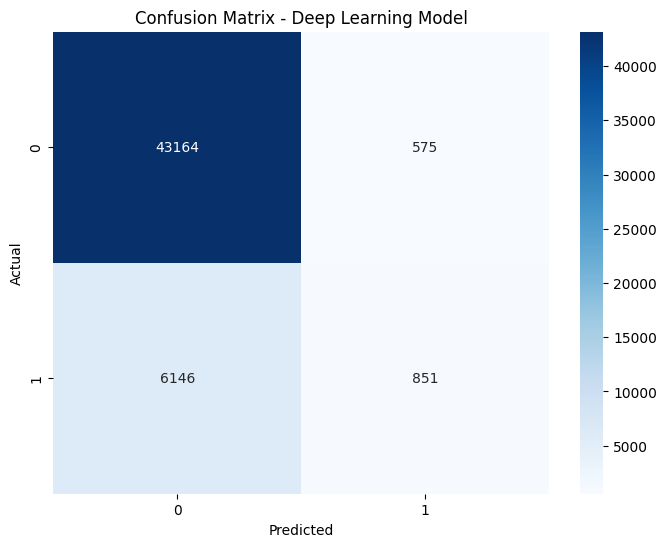

In [49]:
# Predictions
if len(np.unique(y_train)) == 2:
    y_pred_prob = model.predict(X_test_scaled)
    y_pred = (y_pred_prob > 0.5).astype("int32")
else:
    y_pred_prob = model.predict(X_test_scaled)
    y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("✅ Deep Learning Model Accuracy:", accuracy_score(y_test, y_pred))
print("✅ Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Deep Learning Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [50]:
model.save('deep_learning_diabetes_model.h5')

1586/1586 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
✅ Accuracy: 0.867529959003469
✅ Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.99      0.93     43739
         1.0       0.60      0.12      0.20      6997

    accuracy                           0.87     50736
   macro avg       0.74      0.55      0.56     50736
weighted avg       0.84      0.87      0.83     50736



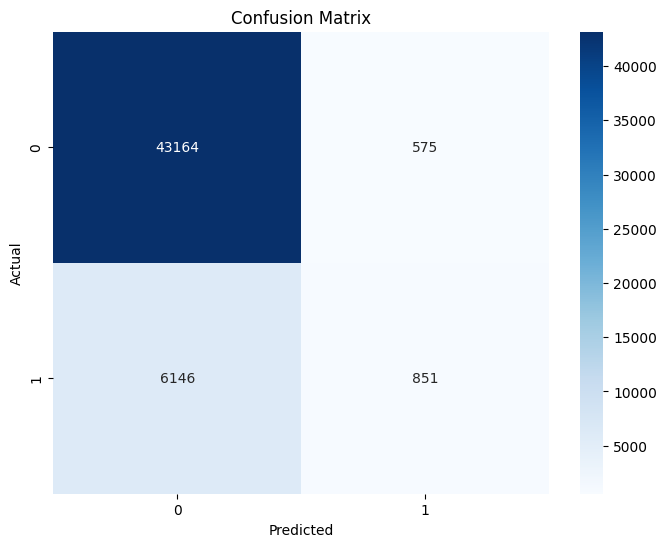

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# For binary classification
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int32")

# For multiclass (uncomment if you used categorical encoding)
# y_pred_prob = model.predict(X_test_scaled)
# y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("✅ Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [52]:
X = df.drop('Diabetes_binary', axis=1)  # 21 features
y = df['Diabetes_binary']


In [53]:
# Corrected input without the target column
new_data = np.array([[1, 1, 1, 32.5, 1, 0, 0, 1, 1, 1, 0, 1, 0, 3, 0, 5, 0, 1, 8, 4, 3]])
# Now it has 21 features — matches what StandardScaler expects
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
print("Prediction:", "Diabetes" if prediction[0][0] > 0.5 else "No Diabetes")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
Prediction: No Diabetes


In [54]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [55]:
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save model
model.save("diabetes_model.h5")


In [56]:
import joblib
joblib.dump(scaler, "scaler.pkl")
model.save("diabetes_model.h5")


In [57]:
model.save("diabetes_model.keras")


In [58]:
from keras.models import load_model

model = load_model("diabetes_model.keras")


In [59]:
from google.colab import files
files.download("diabetes_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


In [61]:
from google.colab import files
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/healthcare_project/Dataset.csv")

# Check structure
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DPF', 'Age', 'Outcome'],
      dtype='object')


In [63]:
# Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load the dataset
df = pd.read_csv("/content/drive/MyDrive/healthcare_project/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# Step 2: Separate features (X) and target (y)
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Model training
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 5: Model prediction
y_pred = model.predict(X_test)

# Step 6: Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", report)


Model Accuracy: 73.71%

Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.69      0.73      7090
         1.0       0.72      0.78      0.75      7049

    accuracy                           0.74     14139
   macro avg       0.74      0.74      0.74     14139
weighted avg       0.74      0.74      0.74     14139



In [65]:
# Assign Patient ID if not present
for df in [symptom_df, profile_df, heart_df, diabetes_df]:
    if 'Patient_ID' not in df.columns:
        df['Patient_ID'] = range(1, len(df) + 1)

# Merge all datasets on 'Patient_ID'
merged_df = symptom_df.merge(profile_df, on='Patient_ID') \
                      .merge(heart_df, on='Patient_ID', how='outer') \
                      .merge(diabetes_df, on='Patient_ID', how='outer')


In [66]:
# Fill or drop missing values
merged_df = merged_df.fillna(0)  # or use dropna() if preferred

In [67]:
# X = all columns except the target
X = diabetes_df.drop("Diabetes_binary", axis=1)

# y = target column
y = diabetes_df["Diabetes_binary"]


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [69]:
from sklearn.ensemble import RandomForestClassifier

diabetes_model = RandomForestClassifier(n_estimators=100, random_state=42)
diabetes_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [70]:
from sklearn.metrics import accuracy_score

y_pred = diabetes_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Diabetes Model Accuracy: {accuracy:.2f}")


Diabetes Model Accuracy: 0.86


In [71]:
# Create a dummy patient with all the required features
new_patient = pd.DataFrame([{
    'HighBP': 1,
    'HighChol': 1,
    'CholCheck': 1,
    'BMI': 30,
    'Smoker': 0,
    'Stroke': 0,
    'HeartDiseaseorAttack': 0,
    'PhysActivity': 1,
    'Fruits': 1,
    'Veggies': 1,
    'HvyAlcoholConsump': 0,
    'AnyHealthcare': 1,
    'NoDocbcCost': 0,
    'GenHlth': 3,
    'MentHlth': 2,
    'PhysHlth': 2,
    'DiffWalk': 0,
    'Sex': 1,
    'Age': 9,
    'Education': 4,
    'Income': 6
}])


In [72]:
import joblib

# Save the trained model
joblib.dump(model, 'diabetes_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [73]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pickle

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/healthcare_project/diabetes_binary_health_indicators_BRFSS2015.csv")
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Define model
model = Sequential()
model.add(Dense(32, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

# Compile
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train
model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Save model
model.save("diabetes_model.keras")


Epoch 1/20
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8624 - loss: 0.3310 - val_accuracy: 0.8659 - val_loss: 0.3142
Epoch 2/20
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8656 - loss: 0.3160 - val_accuracy: 0.8655 - val_loss: 0.3144
Epoch 3/20
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8657 - loss: 0.3141 - val_accuracy: 0.8660 - val_loss: 0.3150
Epoch 4/20
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8675 - loss: 0.3136 - val_accuracy: 0.8660 - val_loss: 0.3145
Epoch 5/20
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8662 - loss: 0.3134 - val_accuracy: 0.8669 - val_loss: 0.3130
Epoch 6/20
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8659 - loss: 0.3120 - val_accuracy: 0.8670 - val_loss: 0.3126
Epoch 7/20
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8672 - loss: 0.3114 - val_accuracy: 0.8668 - val_loss: 0.3128
Epoch 8/20
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8660 - loss: 0

In [74]:
# diabetes_model_builder.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/healthcare_project/diabetes_binary_health_indicators_BRFSS2015.csv")  # Adjust path as needed

# Separate features and label
X = df.drop(columns=["Diabetes_binary"])  # Feature columns
y = df["Diabetes_binary"]  # Target column

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define deep learning model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train_scaled, y_train, epochs=10, validation_split=0.1)

# Save model and scaler
model.save("diabetes_model.keras")
import joblib
joblib.dump(scaler, "scaler.pkl")


Epoch 1/10
5708/5708 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8562 - loss: 0.3343 - val_accuracy: 0.8658 - val_loss: 0.3149
Epoch 2/10
5708/5708 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8663 - loss: 0.3125 - val_accuracy: 0.8661 - val_loss: 0.3139
Epoch 3/10
5708/5708 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8683 - loss: 0.3104 - val_accuracy: 0.8655 - val_loss: 0.3139
Epoch 4/10
5708/5708 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8670 - loss: 0.3119 - val_accuracy: 0.8660 - val_loss: 0.3149
Epoch 5/10
5708/5708 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8668 - loss: 0.3114 - val_accuracy: 0.8657 - val_loss: 0.3141
Epoch 6/10
5708/5708 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8684 - loss: 0.3096 - val_accuracy: 0.8659 - val_loss: 0.3139
Epoch 7/10
5708/5708 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8681 - loss: 0.3102 - val_accuracy: 0.8662 - val_loss: 0.3138
Epoch 8/10
5708/5708 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8687 - loss: 0

['scaler.pkl']

In [75]:
from tensorflow.keras.models import load_model

model = load_model("diabetes_model.keras")


In [76]:
from google.colab import files
files.download('diabetes_model.keras')
files.download('scaler.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pickle

# Load dataset
from sklearn.datasets import load_diabetes
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model
model = Sequential([
    Dense(16, input_shape=(X.shape[1],), activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)

# Save model and scaler
model.save("diabetes_model.keras")
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model and scaler saved!")


✅ Model and scaler saved!
